In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
from edes.utils.file_handling import list_filepaths, list_files_in_time_range
from edes.experiments.analysis.lock_in_detection import plot_individual_PvT, plot_hist, compare_hist_U2_Ex_continuous_loading, \
                                                        plot_Prob_vs_var, compare_PvT_U2_Ex_continuous_loading, plot_PvT_across_var, \
                                                        plot_hist_across_var, plot_peak_power_vs_var, power_in_unit
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import datetime
import pandas as pd

import json
import os
import re
big_plt_font()

In [2]:
home_dir = '/home/electron/'
data_dir = home_dir + f'artiq/experiment/artiq-master/results/{datetime.datetime.now().strftime("%Y-%m-%d")}'
results_base_dir = os.path.join(home_dir, 'artiq/experiment/artiq-master/results/')

In [3]:
def load_artiq_h5_arguments(filename, arg, base=''):
    return json.loads(load_h5_data(filename, base=base)['expid'])['arguments'][arg]

In [4]:
def find_file_by_rid(rid, search_dir, base_dir_to_strip):
    """Searches for an ARTIQ .h5 file matching the given RID."""
    target_prefix = f"{int(rid):09d}-"
    for root, dirs, files in os.walk(search_dir):
        for file in files:
            if file.startswith(target_prefix) and file.endswith('.h5'):
                full_path = os.path.join(root, file)
                # Strip the home_dir from the start so load_h5_data works correctly with base=home_dir
                if full_path.startswith(base_dir_to_strip):
                    return full_path[len(base_dir_to_strip):]
                return full_path
    return None


Processing With FB, outside box from artiq/experiment/artiq-master/results/2026-08-18/10/000010914-FeedbackWithSingleConfig.h5
Processing With FB, inside box from artiq/experiment/artiq-master/results/2026-08-18/14/000010958-FeedbackWithSingleConfig.h5
Processing Without FB from artiq/experiment/artiq-master/results/2026-08-18/14/000010960-FeedbackWithSingleConfig.h5


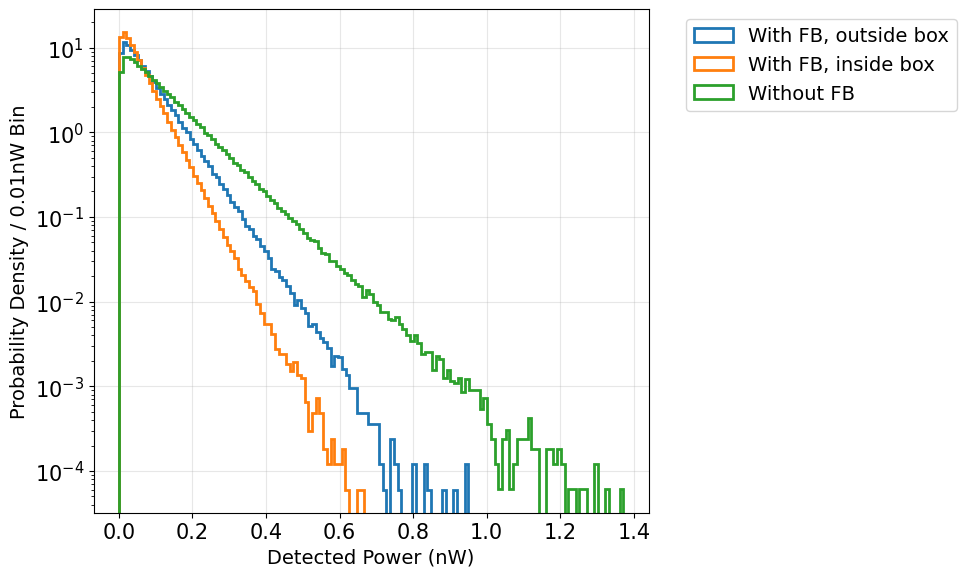

In [ ]:
N_data_SWT = 751

# --- Power units: set to 'nW' or 'dBm' and re-run this cell -------------
UNIT = 'nW'
BIN_SIZE = {'nW': 0.01, 'dBm': 0.1}[UNIT]   # histogram bin width, in UNIT

# 1. Define your RIDs here. Use (RID, "Label") for custom names, or just RID for default.
rids_to_plot = [
    (11283, "Background"),
    # (10958, "With FB, inside box"),
    # (10960, "Without FB")
]

plt.figure(figsize=(10, 6))

# 2. Loop through the list
for item in rids_to_plot:
    # Check if the item is a tuple (has a custom label) or just an integer
    if isinstance(item, tuple):
        rid, label = item
    else:
        rid, label = item, f"RID {item}"
        
    filename = find_file_by_rid(rid, results_base_dir, home_dir)
    
    if not filename:
        print(f"Could not find file for RID: {rid}. Skipping.")
        continue
        
    print(f"Processing {label} from {filename}")
    
    file = load_h5_data(filename, base=home_dir)['datasets']
    SWT = load_artiq_h5_arguments(filename, 'SSA_SWT', base=home_dir)
    
    all_powers = []
    for i in file: 
        if i[:8] == 'all_meas': 
            powers = file[i] 
            if len(powers) > 0:
                index = int(i[9:]) 
                time_stamp = file[f'time_stamps_{index}']
                for j in range(len(time_stamp)): 
                    all_powers.extend(powers[j])
            
    if len(all_powers) == 0:
        print(f"No power data found in {label}. Skipping.")
        continue

    # Process powers
    P, _ = power_in_unit(np.array(all_powers).flatten(), UNIT)
    
    # Calculate bins
    num_bins = max(int((max(P) - min(P)) / BIN_SIZE), 1)
    
    # Get the next color from matplotlib's color cycle
    color = plt.gca()._get_lines.get_next_color()
    
    # Plot the histogram using the resolved label
    plt.hist(P, bins=num_bins, density=True, histtype='step', linewidth=2, 
             color=color, label=label)

# Final plot formatting
plt.xlabel(f'Detected Power ({UNIT})') 
plt.ylabel(f'Probability Density / {BIN_SIZE} {UNIT} Bin')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.show()